## データの整理
### AISによる予測データ
lat, lonの範囲
LatIdxMax = 1500
LatIdxMin = 600
LonIdxMax = 4500
LonIdxMin = 3510<br>
AIS5は-9時間のずれ<br>
AIS4はMmsi,DtIdx,LatIdx,LonIdx,ThetaDeg,F,LineCount<br>
グリッド間隔：0.03333334,時間間隔：01:00:00<br>
DtIdx=Round((DateTime-#2011/1/1 00:00UTC#)/グリッド間隔)<br>
LatIdx=Round(Deg/グリッド間隔)<br>

### JCOPEのデータ
1°あたりのメッシュ数36

eas：解析値（nowcast<br>
Lat 20-1/36～50+1/36°(30*36+2=1082個)<br> 
Lon 117-1/36～150+1/36°(33*36+2=1190個)<br>

nedo：再解析値<br>
Lat 24-1/36～48+1/36° Lon 125-1/36～148+1/36°<br>

Item: U, V （Uは東向き Vは北向き 単位m/s）表層のみ 4bytes float<br>
の値を持っている。また、陸など未定義値として1e+20を使用する。<br>


In [2]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns

### パラメータ設定

In [3]:
deg_per_mesh = 1/36
ais_lat_max = 1800
ais_lat_min = 750
ais_lon_max = 5401
ais_lon_min = 4211
lat_range = [20-1/36, 50+1/36]
lon_range = [117-1/36, 150+1/36]
map_size_ais = [1050, 1191]
map_size_jcope = [1082, 1191]

## 関数の定義

In [4]:
# dummpy jcope data
# data: 1*(n+m)
def dummy_jcope_data(x0, dx, count, noise_factor, size=[10, 10]):
    data = []
    for i in range(count):
        data.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        data[i].append(0)
    return data

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data(x0, dx, omega, count, noise_factor, size=[10, 10]):
    xy = []
    sum_w = []
    for i in range(count):
        xy.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        xy[i].append(1)
        sum_w[i].append(0.00001)
    return xy, sum_w

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data2(x0, dx, omega, count, noise_factor, size=[10, 10]):
    v = []
    theta = []
    sum_w = []
    for i in range(count):
        v.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        theta.append([x0+ omega*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        v[i].append(1)
        theta[i].append(0)
        sum_w[i].append(0)
    return v, theta, sum_w

# lat lon -> mesh 
def latlon_to_mesh(lat, lon, size=[865, 831]):
    lat_range = lat_range
    lon_range = lon_range
    # lat, lon -> [lon, lat]
    grid0 = int((lon-lon_range[1])/deg_per_mesh)
    grid1 = int((lat-lat_range[0])/deg_per_mesh)
    if grid0<0 or grid0>size[0]: return [-1, -1]
    if grid1<0 or grid1>size[1]: return [-1, -1]
    return [grid0, grid1]

def aisIdx_to_rallon(lat_idx, lon_idx):
    return [lat_idx, lon_idx]*deg_per_mesh

# JCOPE
jcope_data = dummy_jcope_data(0, 0.1, 100, 0.01)

# AIS(観測値) 
ais_data = dummy_ais_data(0, 0.1, 1, 100, 0.001)

## データの読み込み
JCOPEはeasデータを使用<br>
AISはeasのグリッドに合わせるとでコードできないのでlatidxminの値を大きくした<br>
eas grid size = (1081, 1191)<br>
ais grid size = (1050, 1191) // grid size (1079, 1191)より大きいとエラー？<br>

In [5]:
# pathの設定
path_ais = [ fr'./data/kankyo/AisCurr2015123115N.csv']

ais_n_mapped = []
for i, p in enumerate(path_ais):
    ais_n_mapped.append(pd.read_csv(p, encoding="cp932",))

    

### データの確認

AIS N:(1050, 1191)


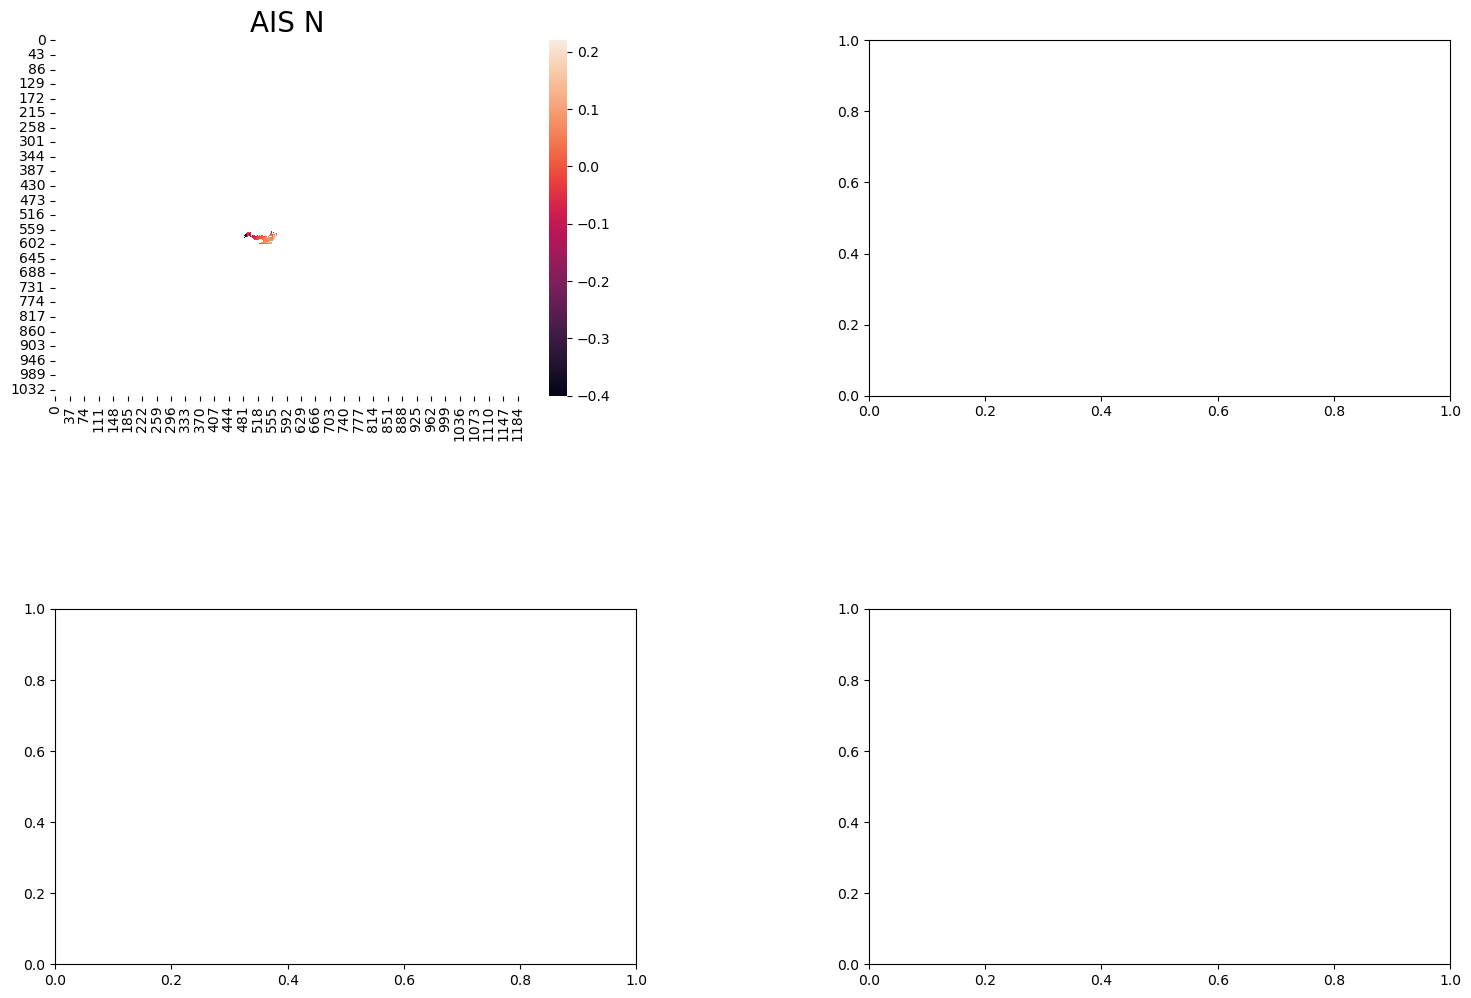

In [6]:
datas = [ais_n_mapped[0]]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

### なんかAIS5データが変なので，AIS4データからMeshで偏流を計算してみる
とりあえずデータの確認

In [7]:
ais.head()

,Mmsi,DtIdx,LatIdx,LonIdx,ThetaDeg,F,LineCount
0,209225000,41319,1253,4647,144.000000,1.401389e-07,2.000000
1,209225000,41319,1253,4648,144.000002,1.273990e-08,11.000000
2,209225000,41319,1254,4648,323.999994,1.439823e-01,32.000005
3,209225000,41319,1254,4649,324.000001,5.235720e-03,44.000018
4,209225000,41319,1255,4649,324.000000,1.151859e-01,2.000000


In [8]:
# 各船のデータ数
pd.value_counts(ais['Mmsi'])

431600641    377
431100945    373
431004083    358
431006385    353
311595000    345
            ... 
259002000      1
413465360      1
413442920      1
413378260      1
311033400      1
Name: Mmsi, Length: 3037, dtype: int64

In [9]:
# 時刻データ (3hr分)
# pd.value_counts(ais['DtIdx'])
set(ais['DtIdx'].values)

{41319,
 41320,
 41321,
 41322,
 41323,
 41324,
 41325,
 41326,
 41327,
 41328,
 41329,
 41330,
 41331,
 41332,
 41333,
 41334,
 41335,
 41336,
 41337,
 41338,
 41339,
 41340,
 41341,
 41342,
 41343}

<Axes: xlabel='LatIdx', ylabel='LonIdx'>

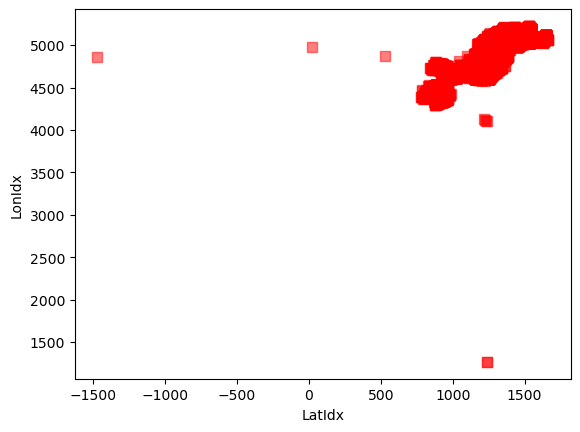

In [10]:
# データの位置
ais.plot.scatter(x='LatIdx', y='LonIdx',
                marker='s', c='r', s=50, alpha=0.5)

### データの整理

In [52]:
# 指定した範囲内のlat lonだけ使う
lat_range2 = (np.array(lat_range)*36).astype(np.int64)
lon_range2 = (np.array(lon_range)*36).astype(np.int64)
ais2 = ais[ais['LatIdx']-lat_range2[0]>=0]
ais2 = ais2[ais2['LatIdx']-lat_range2[0]<=map_size_jcope[0]]
ais2 = ais2[ais2['LonIdx']-lon_range2[0]>=0]
ais2 = ais2[ais2['LonIdx']-lon_range2[0]<=map_size_jcope[1]]
ais2['LatIdx2'] = ais2['LatIdx'] - lat_range2[0]
ais2['LonIdx2'] = ais2['LonIdx'] - lon_range2[0]

# 実数値のlat, lon
ais2['lat'] = ais2['LatIdx'].values*deg_per_mesh
ais2['lon'] = ais2['LonIdx'].values*deg_per_mesh

# 時間の整理
min_time = min(set(ais['DtIdx'].values))
ais2['time'] = ais2['DtIdx'].values-min_time
print(f"time: {set(ais2['time'].values)}")
if (len(set(ais2['time'].values))!=25):
    print("Check data. Time exist Error.")

# 信頼できる値を残す
ais2 = ais2[ais2["LineCount"]>=0.1]

# 分散の計算
ais2["sigma"] = 1/(2*ais2["LineCount"])

ais2.head()

time: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24}


,Mmsi,DtIdx,LatIdx,LonIdx,ThetaDeg,F,LineCount,LatIdx2,LonIdx2,lat,lon,time,sigma
0,209225000,41319,1253,4647,144.000000,1.401389e-07,2.000000,534,436,34.805556,129.083333,0,0.250000
1,209225000,41319,1253,4648,144.000002,1.273990e-08,11.000000,534,437,34.805556,129.111111,0,0.045455
2,209225000,41319,1254,4648,323.999994,1.439823e-01,32.000005,535,437,34.833333,129.111111,0,0.015625
3,209225000,41319,1254,4649,324.000001,5.235720e-03,44.000018,535,438,34.833333,129.138889,0,0.011364
4,209225000,41319,1255,4649,324.000000,1.151859e-01,2.000000,536,438,34.861111,129.138889,0,0.250000


In [69]:
print(f"lat range{lat_range2}")
print(f"lon range{lon_range2}")

lat range[ 719 1801]
lon range[4211 5401]


<Axes: xlabel='LonIdx2', ylabel='LatIdx2'>

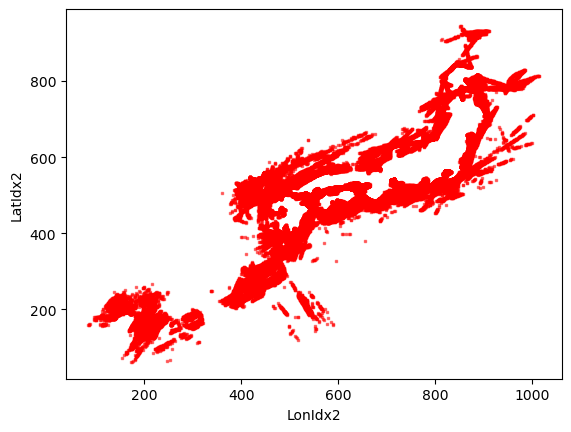

In [55]:
ais2.plot.scatter(x='LonIdx2', y='LatIdx2',
                marker='s', c='r', s=1, alpha=0.5)

## 偏流の計算（観測値の計算）
パラメータと関数

In [32]:
# parameter
HalfLat = 0.1    # 半減距離緯度方向deg 0.037
HalfLon = 0.2    # 半減距離経度方向deg 0.064
degPerMesh = deg_per_mesh 

ln2 = 0.6931471805599453094172321
Thres = 0.05 # これ以下の重みになるような距離は無視
LatRange = (int)(-HalfLat * np.log(Thres) / ln2 / degPerMesh) # Thresに到達するメッシュインデックス差（緯度方向）
LonRange = (int)(-HalfLon * np.log(Thres) / ln2 / degPerMesh) # 同経度方向
lat_range2 = (np.array(lat_range)*36).astype(np.int64)
lon_range2 = (np.array(lon_range)*36).astype(np.int64)

nan_map = np.array(jcope_n[0].values)*0+1

def weight(lat, lon):
    return np.exp(-ln2 * np.sqrt((lat * degPerMesh / HalfLat)**2 + (lon * degPerMesh / HalfLon)**2))
print(LatRange)
print(LonRange)

15
31


各時間のAISを計算

In [63]:
import tqdm
import copy

ais_n = []
ais_e = []
ais_sigmas = []
# time_set = set(ais2["time"].astype(int)) # all time
time_set = [0]
for t in time_set:
    ais_gridN = np.zeros(nan_map.shape)*nan_map
    ais_gridE = np.zeros(nan_map.shape)*nan_map
    ais_A11 = np.zeros(nan_map.shape)*nan_map
    ais_A12 = np.zeros(nan_map.shape)*nan_map
    ais_A22 = np.zeros(nan_map.shape)*nan_map
    ais_B1 = np.zeros(nan_map.shape)*nan_map
    ais_B2 = np.zeros(nan_map.shape)*nan_map
    ais_sumw = np.zeros(nan_map.shape)
    ais_sigma = np.ones(nan_map.shape)*np.inf

    data = ais2[ais2["time"]==t]
    lat_lon_set = set((data["LatIdx"]-lat_range2[0]).astype(int).astype(str) + " " 
                  + (data["LonIdx"]-lon_range2[0]).astype(int).astype(str))
    skip_count = 0
    for lat_lon in tqdm.tqdm(lat_lon_set):
        target_tf = (lat_lon == ((data["LatIdx"]-lat_range2[0]).astype(int).astype(str) + " " 
                                 + (data["LonIdx"]-lon_range2[0]).astype(int).astype(str)))
        target = data[target_tf]
        lat = int(target["LatIdx"].values[0]-lat_range2[0])
        lon = int(target["LonIdx"].values[0]-lon_range2[0])
        for i in range(-LatRange, LatRange+1):
            for j in range(-LonRange, LonRange+1):
                if lat+i < 0 or lat+i>=map_size[0]: continue
                if lon+j <= 0 or lon+j>map_size[1]: continue
                L = target['LineCount'].values
                w = weight(i, j)*L
                cos = np.cos(target['ThetaDeg'].values*np.pi/180)
                sin = np.sin(target['ThetaDeg'].values*np.pi/180)
                coscos = np.sum(w*cos**2)
                sinsin = np.sum(w*sin**2)
                sincos = np.sum(w*sin*cos)
                cosF = np.sum(w*cos*target['F'].values)
                sinF = np.sum(w*sin*target['F'].values)
                ais_A11[map_size_jcope[0]-lat-i][lon+j] += coscos
                ais_A12[map_size_jcope[0]-lat-i][lon+j] += sincos
                ais_A22[map_size_jcope[0]-lat-i][lon+j] += sinsin
                ais_B1[map_size_jcope[0]-lat-i][lon+j] += cosF
                ais_B2[map_size_jcope[0]-lat-i][lon+j] += sinF
                ais_sumw[map_size_jcope[0]-lat-i][lon+j] += np.sum(w)
                    

    A_abs = ais_A11*ais_A22 - ais_A12*ais_A12
    tf = A_abs>=1
    print(f"Used data num: {np.sum(tf)}" )

    ais_gridN[tf] = (ais_A22*ais_B1 - ais_A12*ais_B2)[tf] / A_abs[tf]
    ais_gridE[tf] = (-ais_A12*ais_B1 + ais_A11*ais_B2)[tf] / A_abs[tf]
    ais_gridN *= nan_map
    ais_gridE *= nan_map
    ais_n.append(copy.deepcopy(ais_gridN))
    ais_e.append(copy.deepcopy(ais_gridE))
    
    tf = ais_sumw != 0
    ais_sigma[tf] = 1/(2*ais_sumw[tf])
    ais_sigmas.append(ais_sigma)
    print("Finished computing cur")

100%|██████████████████████████████████████████████████████████████████████████████| 3766/3766 [08:43<00:00,  7.19it/s]

Used data num: 93967
Finished computing cur


### データの可視化

AIS N:(1081, 1191)
AIS E:(1081, 1191)
AIS N(ais5):(1050, 1191)
AIS E(ais5):(1050, 1191)
sigma:(1081, 1191)


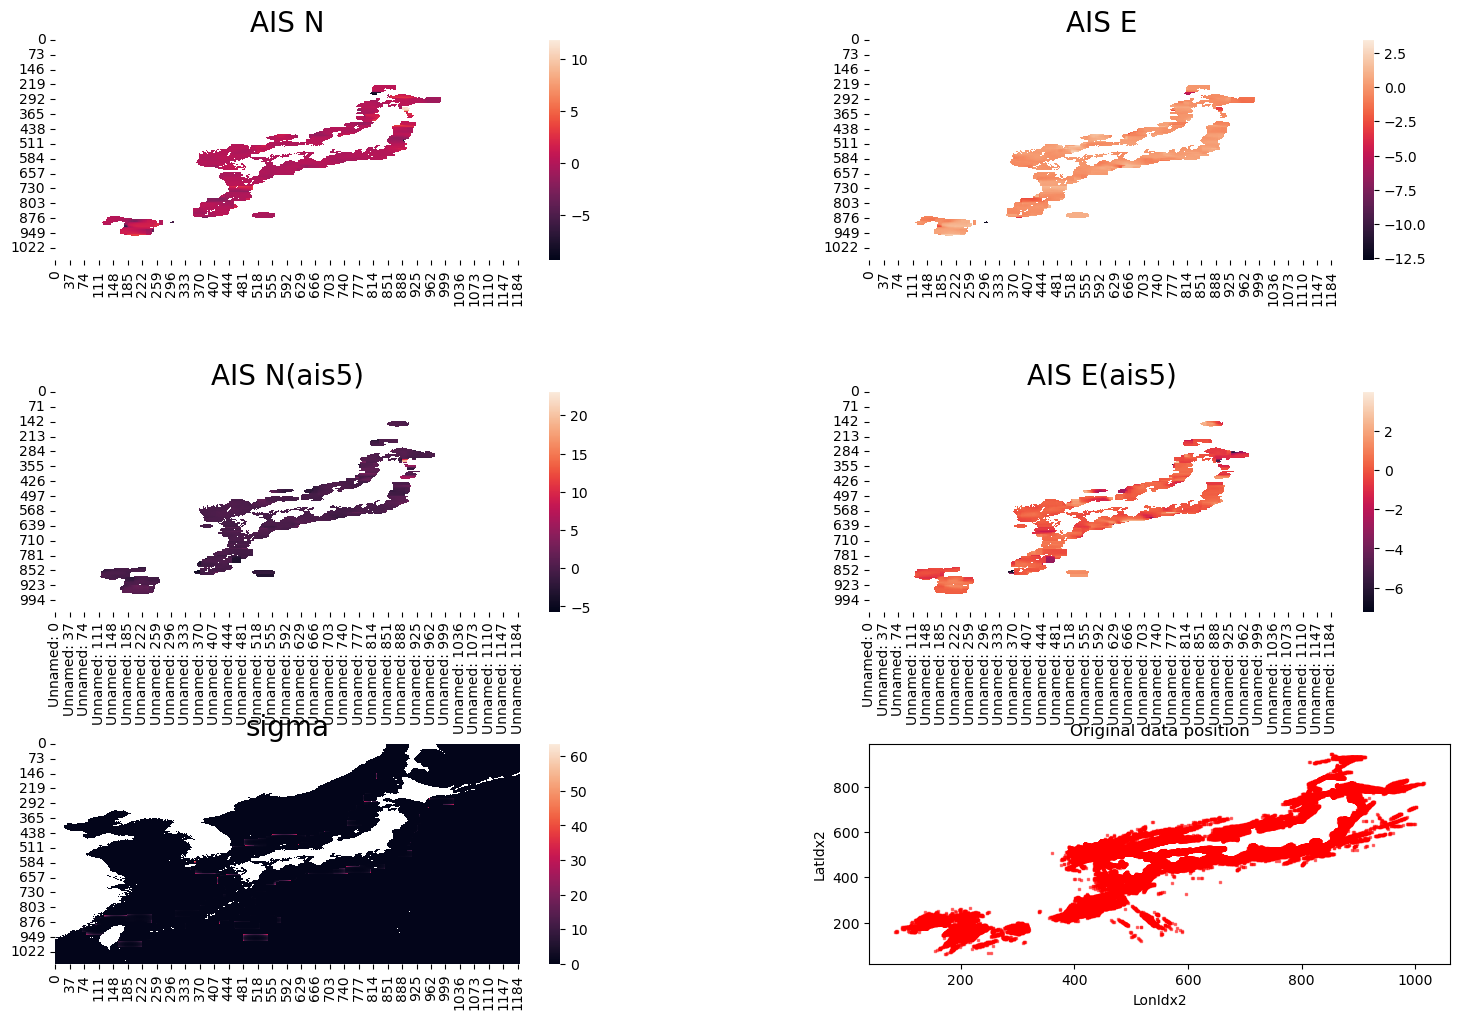

In [70]:
tf = A_abs>=1
sigma = ais_sigma*nan_map
sigma[sigma==np.inf] = 0
ais_gridN[ais_gridN==0.0] = np.nan
ais_gridE[ais_gridE==0.0] = np.nan
datas = [ais_gridN, ais_gridE, ais_n_mapped[0], ais_e_mapped[0], sigma]
data_names = ['AIS N', 'AIS E', "AIS N(ais5)", "AIS E(ais5)", 'sigma']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1], [2, 0], [2,1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data, ax=axes[a, b])
ais2.plot.scatter(x='LonIdx2', y='LatIdx2',
                marker='s', c='r', s=1, alpha=0.5, ax=axes[2,1], title="Original data position")
plt.show()

|AIS5 - AIS N| > 1:(1050, 1191)
|AIS5 - AIS E| > 1:(1050, 1191)


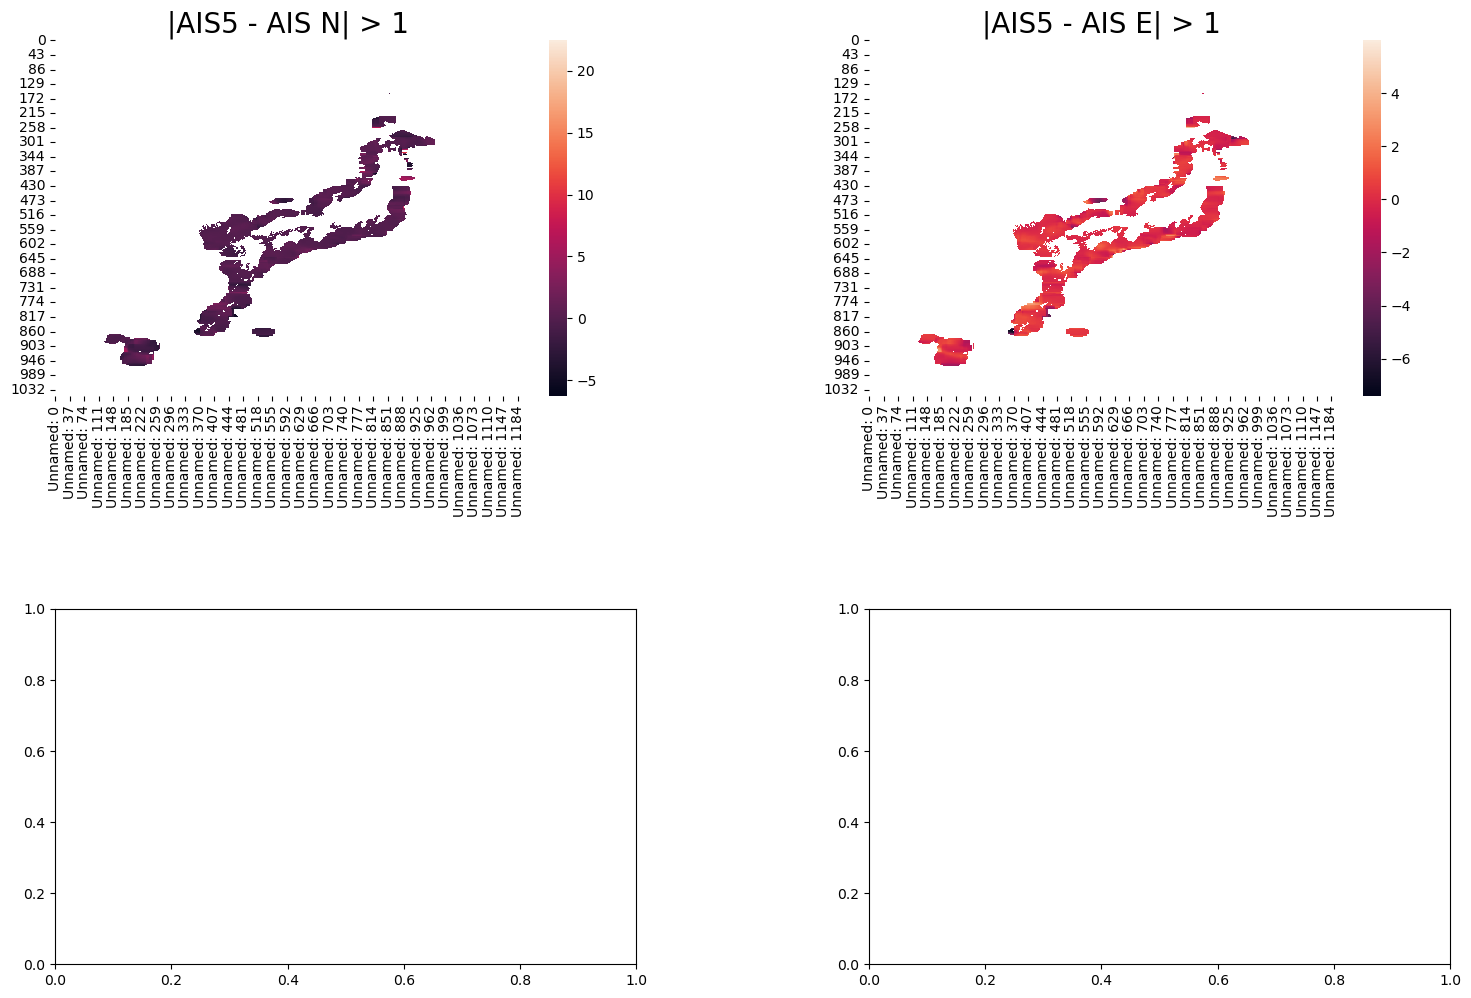

In [83]:
tf = A_abs>=1
sigma = ais_sigma*nan_map
sigma[sigma==np.inf] = 0
ais_gridN[ais_gridN==0.0] = np.nan
ais_gridE[ais_gridE==0.0] = np.nan
tes1 = ais_n_mapped[0]-ais_gridN[0:1050]
tes1[np.abs(tes1)<1] = np.nan 
tes2 = ais_e_mapped[0]-ais_gridE[0:1050]
tes2[np.abs(tes1)<1] = np.nan
datas = [ais_n_mapped[0]-ais_gridN[0:1050], ais_e_mapped[0]-ais_gridE[0:1050]]
data_names = ['|AIS5 - AIS N| > 1', '|AIS5 - AIS E| > 1']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1], [2, 0], [2,1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data, ax=axes[a, b])
plt.show()

### 最大値の差とデータの分布の違いが気になる
どこかの閾値でやらかした？<br>
座標指定間違ってる？


### データの保存

In [ ]:
import pickle
with open('data/ais/20150919/AIS_N_20150919.pickle', 'wb') as f:
    pickle.dump(ais_n, f)

with open('data/ais/20150919/AIS_E_20150919.pickle', 'wb') as f:
    pickle.dump(ais_e, f)

with open('data/ais/20150919/AIS_SIGMA_20150919.pickle', 'wb') as f:
    pickle.dump(ais_sigmas, f)

## カルマンフィルタの設計
### 状態空間モデル
$\hat{x(t)}^{-} = A\hat{x}(t-1)$<br>
$\hat{x(t)}^{-} = J(K) + a(\hat{x}(t-1)-J(k-1))$<br>
$J(k) = \left[ x(0, 0), x(0, 1), \cdots, x(lon-1, lat-1), \cdots, y(0, 0), y(0, 1), \cdots, y(lon-1, lat-1), 1 \right]$<br>
$
A = 
\begin{pmatrix}
   a & 0 & \cdots & 0 & (J(k)-aJ(k-1))(0, 0) \\
   0 & a & \cdots & 0 & (J(k)-aJ(k-1))(0, 1) \\
   \vdots & \cdots &　 &　 & \vdots  \\
   0 & \cdots & 0 & a & (J(k)-aJ(k-1))(lon-1, lat-1)\\
   0 & \cdots & 0 & 1 & 1
\end{pmatrix}
$
<br>
### 観測値
$y(t) = C\hat{x}(t)$<br>
$y(t) = \left[ x(0, 0), x(0, 1), \cdots, x(lon-1, lat-1), \cdots, y(0, 0), y(0, 1), \cdots, y(lon-1, lat-1), 1 \right]$<br>
$
C = 
\begin{pmatrix}
   1 & 0 & \cdots & 0 & 0 \\
   0 & 1 & \cdots & 0 & 0 \\
   \vdots & \cdots &　 &　 & \vdots  \\
   0 & \cdots & 0 & 1 & 0\\
\end{pmatrix}
$

### とりあえず，dummyデータ

In [ ]:
from filterpy.common import Saver
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def F_element(i, j, k, jcope_data):
    a = 0.5
    if i==j:
        if i==n+m:
            return 1
        else:
            return a
    elif j==n+m:
        residual = jcope_data[k][i]-jcope_data[k-1][i]
        return residual
    else:
        return 0

# TODO
def H_element(i, j):
    if i==j:
        return 1
    else:
        return 0
    

n = m = 10
kf = KalmanFilter(dim_x=n+m+1, dim_z=n+m+1)

# data
jcope_data = dummy_jcope_data(0, 0.1, 100, 0.01, size=[n, m])
ais_data, ais_sum_w = dummy_ais_data(0, 0.1, 1, 100, 0.01, size=[n, m])

# F関数, H関数
kf.F = np.array([[F_element(i, j, 1, jcope_data)  for i in range(n+m+1)] for j in range(n+m+1)])
kf.H = np.array([[H_element(i, j)  for i in range(n+m+1)] for j in range(n+m+1)])

# システム雑音共分散行列, 観測雑音共分散行列, 共分散行列　TODO
kf.Q = np.eye(n+m+1)*0.01
kf.R = np.eye(n+m+1)*0.001
kf.P = np.eye(n+m+1)

# 初期位置
kf.x = np.array(jcope_data[0])


s = Saver(kf)
for i in range(1, 6):
    kf.predict()
    kf.update(np.array(ais_data[i]))
    s.save()  # 現在状態を記録する
    
s.to_array()
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
plt.title("Filtered by kalman filter")
plt.xlabel("Time")
plt.ylabel("(0, 0) value")
plt.plot(np.arange(len(s.x[:, 0])), s.x[:, 0], label='res')
plt.scatter(np.arange(len(s.x[:, 0])), s.z[:, 0], label='obs', c='r')
plt.legend()
plt.show()

### real データ
とりあえず，n方向の偏流のみでやってみる


In [ ]:
n = map_size[0]
m = map_size[1]

In [ ]:
from filterpy.common import Saver
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def F_element(i, j, k, jcope_data):
    a = 0.5
    if i==j:
        return a
    elif i==n+m:
        jcope0 = jcope_data[k-1].values.reshape(n*m)
        jcope1 = jcope_data[k].values.reshape(n*m)
        residual = jcope1[i] - jcope0[i]
        return residual
    else:
        return 0

# TODO
def H_element(i, j):
    if i==j:
        return 1
    else:
        return 0
    
def R_mat(sigma):
    R = np.zeros((n*m, n*m+1))
    s = sigma.reshape(1, n*m)
    np.append(s, [0])
    for i in range(len(s)):
        R[i][i] = s[i] 

kf = KalmanFilter(dim_x=n+m+1, dim_z=n+m+1)

# jcope data
jcope_data = jcope_n[0].values.reshape(n*m)
np.append(jcope_data, [1])

# ais data
ais_data = ais_n[0].reshape(1, n*m)
np.append(ais_data, [1])

# F関数, H関数
kf.F = np.array([[F_element(i, j, 1, jcope_n)  for i in range(n+m+1)] for j in range(n+m+1)])
kf.H = np.array([[H_element(i, j)  for i in range(n+m+1)] for j in range(n+m+1)])

# システム雑音共分散行列, 観測雑音共分散行列, 共分散行列　TODO

# システム誤差
kf.Q = np.eye(n+m+1)*0.001
kf.P = np.eye(n+m+1)

# 観測誤差
kf.R = R_mat(ais_sigmas[0])

# 初期位置
kf.x = jcope_data


s = Saver(kf)
t = 0
for i in range(1, 6):
    kf.predict()
    kf.R = R_mat(ais_sigmas[t])
    y = ais_n[i].reshape(1, n*m)
    np.append(y, [1])
    kf.update(y)
    s.save()  # 現在状態を記録する
    t += 1
    
s.to_array()
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
plt.title("Filtered by kalman filter")
plt.xlabel("Time")
plt.ylabel("(0, 0) value")
plt.plot(np.arange(len(s.x[:, 0])), s.x[:, 0], label='res')
plt.scatter(np.arange(len(s.x[:, 0])), s.z[:, 0], label='obs', c='r')
plt.legend()
plt.show()

### サイズが大きすぎて無理なので一部で計算
あとでどのくらいのサイズまで対応できるのか確認する
，陸を除くや黒潮のみでやるなどの工夫がある（by小林さん）

データが多い緯度経度でフィルタリングかけたいので，緯度経度のカウントを表示
(時間軸方向にもデータが散らばってほしいので時間もカウント)

In [ ]:
pd.value_counts((ais2["LatIdx"]-ais_lat_min).astype(int).astype(str) + "," 
                  + (ais2["LonIdx"]-ais_lon_min).astype(int).astype(str)+ "," 
                  + (ais2["time"]).astype(str))

緯度経度が407, 532±5　でフィルタリングしてみる

In [ ]:
n = 10
m = 10

n_range = [532-5, 532+5] 
m_range = [407-5, 407+5]

max_sigma = 10000

jcope_n2 = []
for i in range(len(jcope_n)):
    data = jcope_n[i].values
    data = np.array([d[m_range[0]:m_range[1]] for d in data[n_range[0]:n_range[1]]])
    data = data.reshape(1, n*m)
    data = np.append(data[0], [1])
    data[data==np.nan] = 0
    jcope_n2.append(copy.deepcopy(data))
    
ais_n2 = []
for i in range(len(ais_n)):
    data = ais_n[i]
    data = np.array([d[m_range[0]:m_range[1]] for d in data[n_range[0]:n_range[1]]])
    data = data.reshape(1, n*m)
    data = np.append(data[0], [1])
    data[data==np.nan] = 0
    ais_n2.append(copy.deepcopy(data))
    
ais_sigmas2 = []
for i in range(len(ais_sigmas)):
    data = ais_sigmas[i]
    data = np.array([d[m_range[0]:m_range[1]] for d in data[n_range[0]:n_range[1]]])
    data = data.reshape(1, n*m)
    data = np.append(data[0], [0])
    no_ais_data = ais_n2[i]==0.0
    data[no_ais_data] = max_sigma
    data[data==np.nan] = max_sigma
    data[data==np.inf] = max_sigma
    ais_sigmas2.append(copy.deepcopy(data))

In [ ]:
data = np.array(ais_n2)
tf = data != 0.0
count = np.sum(tf.T, axis=1)
print(f"データがある時間の数:\n{count[0:-1]}") # AISの最後は必ず１なので省いた中でのcountを表示
print(f"データがある時間の数が最大のindex：{np.argmax(count[0:-1])}")

In [ ]:
from filterpy.common import Saver
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def F_element(i, j, k, data):
    a = 0.5
    if i==j:
        return a
    elif i==n+m:
        jcope0 = data[k-1]
        jcope1 = data[k]
        residual = jcope1[i] - jcope0[i]
        return residual
    else:
        return 0

# TODO
def H_element(i, j):
    if i==j:
        return 1
    else:
        return 0
    
def R_mat(sigma):
    R = np.zeros((n*m+1, n*m+1))
    for i in range(len(sigma)):
        R[i][i] = sigma[i]
    return R


kf = KalmanFilter(dim_x=n*m+1, dim_z=n*m+1)

# F関数, H関数
kf.F = np.array([[F_element(i, j, 1, jcope_n2)  for i in range(n*m+1)] for j in range(n*m+1)])
kf.H = np.array([[H_element(i, j)  for i in range(n*m+1)] for j in range(n*m+1)])


# 分散共分散行列
kf.Q = np.eye(n*m+1)*0.001 # システム誤差
kf.R = R_mat(ais_sigmas2[0]) # 観測誤差


kf.x = jcope_n2[0] # 初期位置
kf.P = np.eye(n*m+1) # 初期事後誤差共分散行列
s = Saver(kf) # save用
t = 0
for i in tqdm.tqdm(range(1, len(jcope_n2)-1)):
    # 予測ステップ
    kf.predict()
    
    # フィルタリングステップ
    kf.R = R_mat(ais_sigmas2[t])
    y = ais_n2[i]
    kf.update(y)
    """
    target = 88
    if y[target]!=0.0:
        print(f"t:{t}")
        print(f"R:{kf.R[target][target]}")
        print(f"x:{kf.x[target]}")
        print(f"y:{y[target]}")"""
    s.save()  # 現在状態を記録する
    t += 1
    
    # 関数の更新
    kf.F = np.array([[F_element(i, j, t, jcope_n2)  for i in range(n*m+1)] for j in range(n*m+1)])
    kf.H = np.array([[H_element(i, j)  for i in range(n*m+1)] for j in range(n*m+1)])
    
s.to_array()
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
i = 8
j = 8
plt.title("Filtered by kalman filter")
plt.xlabel("Time")
plt.ylabel(f"({i}, {j}) value")
plt.plot(np.arange(len(s.x[:, i+(j*n)])), s.x[:, i+(j*n)], label='res')
plt.scatter(np.arange(len(s.x[:, i+(j*n)])), s.z[:, i+(j*n)], label='obs', c='r')
plt.legend()
plt.show()

黒潮だけのとこ<br>
メッシュのサイズを大きくする<br>
編集の値はデータ数が少なすぎる<br>